<a href="https://colab.research.google.com/github/adalbertii/Track-optimization/blob/main/VRP_full_solution_10_06_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install -U ortools


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 56.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 wh

Created sample distance matrix 'matrix_distance.csv' with size 15x15.

=== VRP CONSTRAINT SUMMARY ===
Total nodes: 15
Depot node: 0
Vehicles: 5
Vehicle capacity: 120
Vehicle resource capacity: 120
Time horizon: 0 to 240
Node demand range: 5..10 (depot 0)
Node resource demand range: 5..10 (depot 0)
Service time per node: 1
Distance matrix file: matrix_distance.csv

Node details:
Index	Demand	Resource	TimeWindow
0	0	0	0-240
1	5	10	41-72
2	10	5	90-116
3	8	5	171-199
4	9	10	179-228
5	5	6	174-214
6	8	7	18-57
7	5	5	162-187
8	9	6	136-179
9	7	5	62-87
10	10	8	118-150
11	9	7	69-118
12	7	8	163-205
13	9	10	142-169
14	6	7	175-205
=== END CONSTRAINT SUMMARY ===


=== SOLUTION ==
Vehicle 0 route: [0, 1, 6, 9, 11, 10, 12, 8, 7, 3, 0]
  load = 68, resource = 61, distance = 45
  Node details:
    Node 0: demand=0, resource=0, arrival=0, window=0-240
    Node 1: demand=5, resource=10, arrival=41, window=41-72
    Node 6: demand=8, resource=7, arrival=51, window=18-57
    Node 9: demand=7, resource=5, arri

/tmp/ipykernel_8688/193675922.py:301: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", data["num_vehicles"])


Saved VRP solution visualization to vrp_solution.png
Done.


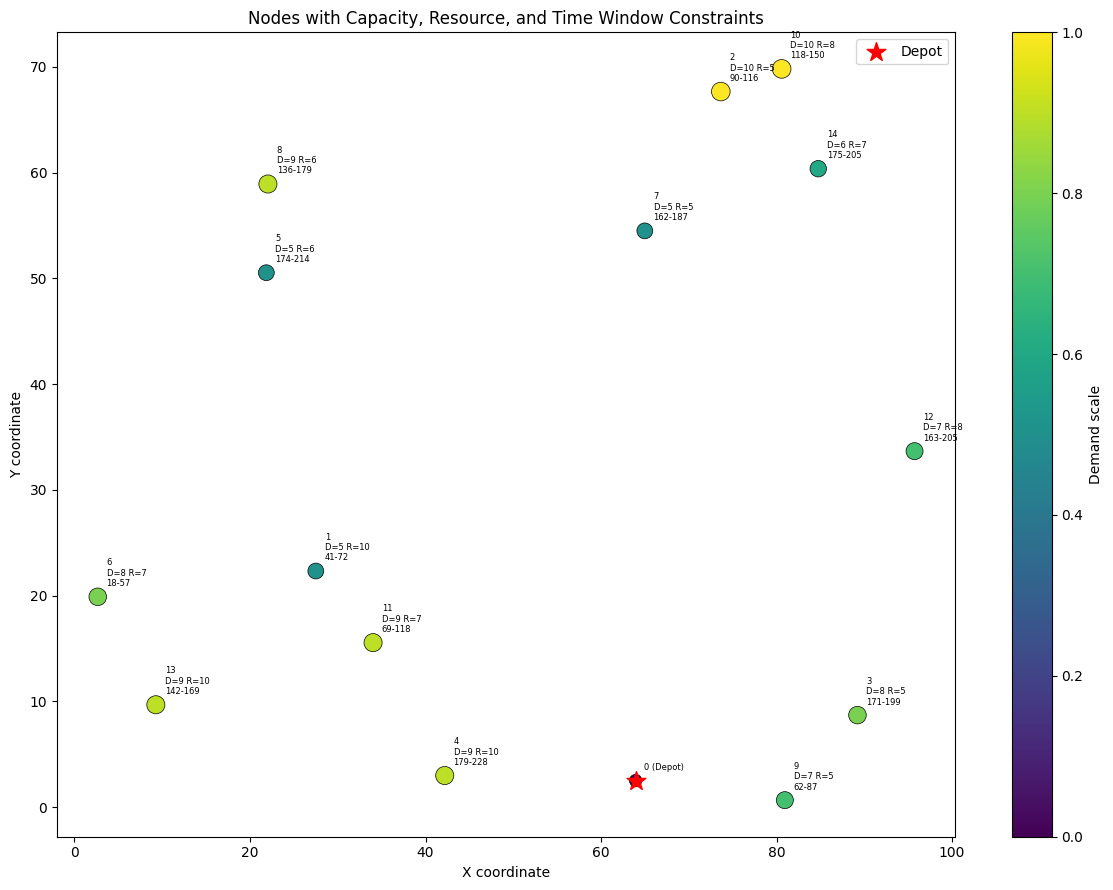

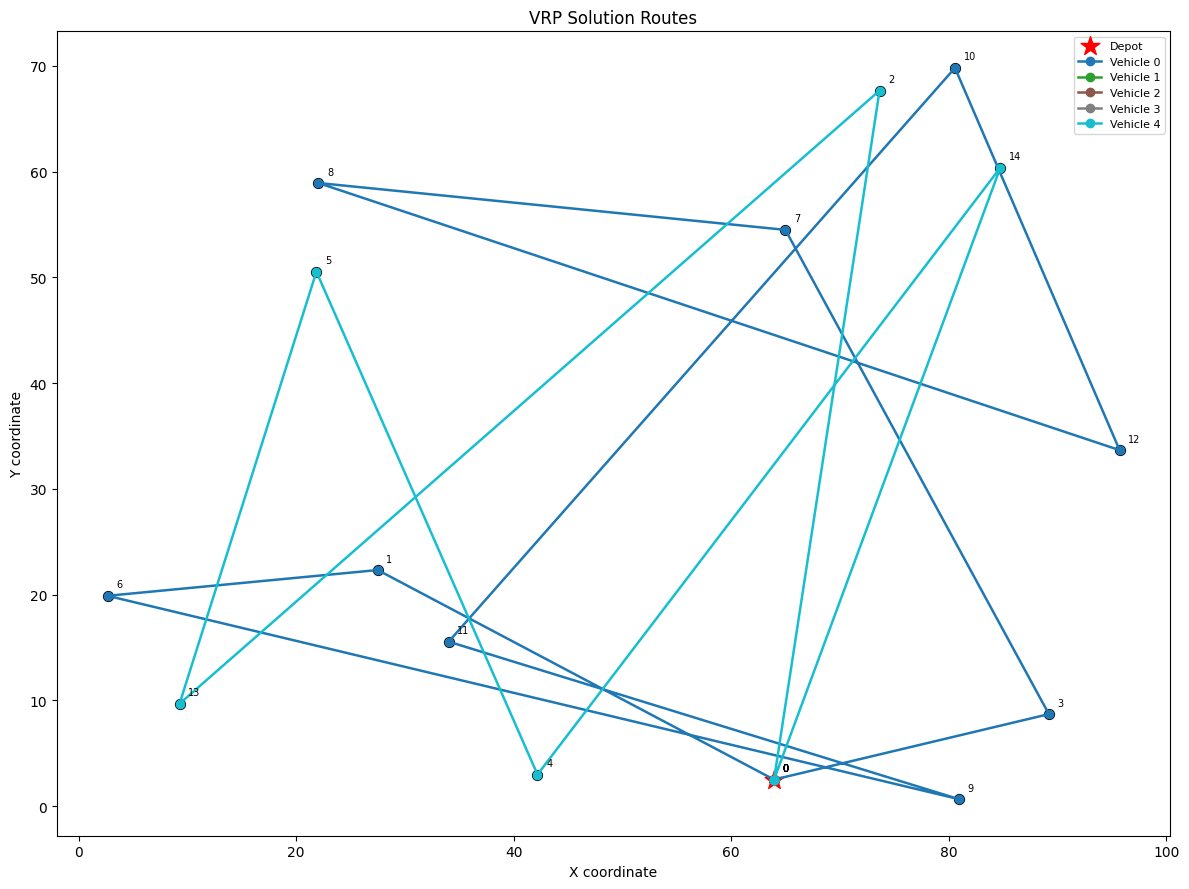

In [7]:
import csv
import os
import random
from typing import List, Tuple

from ortools.constraint_solver import pywrapcp
from ortools.constraint_solver import routing_enums_pb2
import matplotlib.pyplot as plt

NUM_NODES = 15 # Reduced number of nodes
NUM_VEHICLES = 5
DEPOT = 0
CAPACITY = 120
RESOURCE_CAPACITY = 120
SERVICE_TIME = 1
TIME_HORIZON = 240
DISTANCE_MATRIX_FILE = "matrix_distance.csv"


def create_sample_matrix(filename: str, size: int) -> None:
    random.seed(0)
    matrix = [[0] * size for _ in range(size)]
    for i in range(size):
        for j in range(i + 1, size):
            distance = random.randint(1, 20)
            matrix[i][j] = distance
            matrix[j][i] = distance
    with open(filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerows(matrix)
    print(f"Created sample distance matrix '{filename}' with size {size}x{size}.")


def load_distance_matrix(filename: str) -> List[List[int]]:
    with open(filename, "r", newline="") as f:
        reader = csv.reader(f)
        matrix = [[int(cell) for cell in row] for row in reader if row]
    return matrix


def build_data_model() -> dict:
    # Always create a new distance matrix based on current NUM_NODES
    if os.path.exists(DISTANCE_MATRIX_FILE):
        os.remove(DISTANCE_MATRIX_FILE)
    create_sample_matrix(DISTANCE_MATRIX_FILE, NUM_NODES)

    distance_matrix = load_distance_matrix(DISTANCE_MATRIX_FILE)
    if len(distance_matrix) != NUM_NODES or any(len(row) != NUM_NODES for row in distance_matrix):
        raise ValueError(
            f"Distance matrix must be {NUM_NODES}x{NUM_NODES}. Found {len(distance_matrix)}x{len(distance_matrix[0]) if distance_matrix else 0}."
        )

    random.seed(42)
    coordinates: List[Tuple[float, float]] = [
        (random.uniform(0, 100), random.uniform(0, 100)) for _ in range(NUM_NODES)
    ]

    demands = [0] + [random.randint(5, 10) for _ in range(NUM_NODES - 1)]
    resources = [0] + [random.randint(5, 10) for _ in range(NUM_NODES - 1)]

    time_windows = [(0, TIME_HORIZON)]
    for _ in range(NUM_NODES - 1):
        start = random.randint(0, TIME_HORIZON - 50) # Make start times more spread out
        end = start + random.randint(20, 50) # Make time windows wider
        if end > TIME_HORIZON:
            end = TIME_HORIZON
        time_windows.append((start, end))

    return {
        "distance_matrix": distance_matrix,
        "num_vehicles": NUM_VEHICLES,
        "depot": DEPOT,
        "coordinates": coordinates,
        "demands": demands,
        "resources": resources,
        "vehicle_capacities": [CAPACITY] * NUM_VEHICLES,
        "resource_capacities": [RESOURCE_CAPACITY] * NUM_VEHICLES,
        "time_windows": time_windows,
        "service_times": [SERVICE_TIME] * NUM_NODES,
    }


def print_constraints(data: dict) -> None:
    print("\n=== VRP CONSTRAINT SUMMARY ===")
    print(f"Total nodes: {NUM_NODES}")
    print(f"Depot node: {DEPOT}")
    print(f"Vehicles: {NUM_VEHICLES}")
    print(f"Vehicle capacity: {CAPACITY}")
    print(f"Vehicle resource capacity: {RESOURCE_CAPACITY}")
    print(f"Time horizon: 0 to {TIME_HORIZON}")
    print(f"Node demand range: 5..10 (depot 0)")
    print(f"Node resource demand range: 5..10 (depot 0)")
    print(f"Service time per node: {SERVICE_TIME}")
    print(f"Distance matrix file: {DISTANCE_MATRIX_FILE}")
    print("\nNode details:")
    print("Index\tDemand\tResource\tTimeWindow")
    for index in range(NUM_NODES):
        demand = data["demands"][index]
        resource = data["resources"][index]
        tw = data["time_windows"][index]
        print(f"{index}\t{demand}\t{resource}\t{tw[0]}-{tw[1]}")
    print("=== END CONSTRAINT SUMMARY ===\n")


def create_routing_model(data: dict):
    manager = pywrapcp.RoutingIndexManager(
        len(data["distance_matrix"]), data["num_vehicles"], data["depot"]
    )
    routing = pywrapcp.RoutingModel(manager)

    def distance_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        return data["distance_matrix"][from_node][to_node]

    transit_callback_index = routing.RegisterTransitCallback(distance_callback)
    routing.SetArcCostEvaluatorOfAllVehicles(transit_callback_index)

    def demand_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["demands"][from_node]

    demand_callback_index = routing.RegisterUnaryTransitCallback(demand_callback)
    routing.AddDimensionWithVehicleCapacity(
        demand_callback_index,
        0,
        data["vehicle_capacities"],
        True,
        "Capacity",
    )

    def resource_callback(from_index):
        from_node = manager.IndexToNode(from_index)
        return data["resources"][from_node]

    resource_callback_index = routing.RegisterUnaryTransitCallback(resource_callback)
    routing.AddDimensionWithVehicleCapacity(
        resource_callback_index,
        0,
        data["resource_capacities"],
        True,
        "Resource",
    )

    def time_callback(from_index, to_index):
        from_node = manager.IndexToNode(from_index)
        to_node = manager.IndexToNode(to_index)
        travel_time = data["distance_matrix"][from_node][to_node]
        return travel_time + data["service_times"][from_node]

    time_callback_index = routing.RegisterTransitCallback(time_callback)
    routing.AddDimension(
        time_callback_index,
        TIME_HORIZON,
        TIME_HORIZON,
        False,
        "Time",
    )
    time_dimension = routing.GetDimensionOrDie("Time")

    for node in range(NUM_NODES):
        index = manager.NodeToIndex(node)
        start, end = data["time_windows"][node]
        time_dimension.CumulVar(index).SetRange(start, end)

    for vehicle_id in range(NUM_VEHICLES):
        index = routing.Start(vehicle_id)
        time_dimension.CumulVar(index).SetRange(0, TIME_HORIZON)

    routing.AddVariableMinimizedByFinalizer(time_dimension.CumulVar(routing.Start(0)))
    routing.AddVariableMinimizedByFinalizer(time_dimension.CumulVar(routing.End(0)))

    return manager, routing, time_dimension


def solve_vrp(manager, routing, time_dimension):
    search_parameters = pywrapcp.DefaultRoutingSearchParameters()
    search_parameters.first_solution_strategy = (
        routing_enums_pb2.FirstSolutionStrategy.PATH_CHEAPEST_ARC
    )
    search_parameters.local_search_metaheuristic = (
        routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
    )
    search_parameters.time_limit.seconds = 60 # Increased time limit
    search_parameters.log_search = False

    solution = routing.SolveWithParameters(search_parameters)
    if solution:
        return solution
    else:
        raise RuntimeError("No solution found for the VRP with the current constraints.")


def print_solution(data: dict, manager, routing, solution) -> None:
    time_dimension = routing.GetDimensionOrDie("Time")
    total_distance = 0
    total_load = 0
    total_resource = 0

    print("\n=== SOLUTION ==")
    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_distance = 0
        route_load = 0
        route_resource = 0
        route_nodes = []

        while not routing.IsEnd(index):
            node = manager.IndexToNode(index)
            route_nodes.append(node)
            route_load += data["demands"][node]
            route_resource += data["resources"][node]
            previous_index = index
            index = solution.Value(routing.NextVar(index))
            if not routing.IsEnd(index):
                route_distance += routing.GetArcCostForVehicle(previous_index, index, vehicle_id)

        route_nodes.append(manager.IndexToNode(index))

        if len(route_nodes) > 2:
            total_distance += route_distance
            total_load += route_load
            total_resource += route_resource
            print(f"Vehicle {vehicle_id} route: {route_nodes}")
            print(f"  load = {route_load}, resource = {route_resource}, distance = {route_distance}")
            print("  Node details:")
            for node in route_nodes:
                idx = manager.NodeToIndex(node)
                arrival = solution.Min(time_dimension.CumulVar(idx))
                tw = data["time_windows"][node]
                print(
                    f"    Node {node}: demand={data['demands'][node]}, resource={data['resources'][node]}, "
                    f"arrival={arrival}, window={tw[0]}-{tw[1]}"
                )
            print("")

    print(f"Total distance of all routes: {total_distance}")
    print(f"Total load carried: {total_load}")
    print(f"Total resources used: {total_resource}")
    print("=== END SOLUTION ===\n")


def plot_nodes_with_constraints(data: dict) -> None:
    x_coords = [coord[0] for coord in data["coordinates"]]
    y_coords = [coord[1] for coord in data["coordinates"]]
    demand_colors = [d / 10.0 for d in data["demands"]]
    sizes = [80 if i == DEPOT else 80 + d * 10 for i, d in enumerate(data["demands"])]

    fig, ax = plt.subplots(figsize=(12, 9))
    scatter = ax.scatter(
        x_coords,
        y_coords,
        c=demand_colors,
        s=sizes,
        cmap="viridis",
        edgecolors="black",
        linewidths=0.5,
    )
    ax.scatter(
        x_coords[DEPOT], y_coords[DEPOT], c="red", s=200, marker="*", label="Depot"
    )

    for i, (x, y) in enumerate(data["coordinates"]):
        if i == DEPOT:
            label = f"{i} (Depot)"
        else:
            tw = data["time_windows"][i]
            label = f"{i}\nD={data['demands'][i]} R={data['resources'][i]}\n{tw[0]}-{tw[1]}"
        ax.text(x + 1.0, y + 1.0, label, fontsize=6)

    ax.set_title("Nodes with Capacity, Resource, and Time Window Constraints")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.legend(loc="upper right")
    fig.colorbar(scatter, ax=ax, label="Demand scale")
    fig.tight_layout()
    fig.savefig("vrp_nodes_constraints.png", dpi=150)
    print("Saved node constraint visualization to vrp_nodes_constraints.png")


def plot_solution_routes(data: dict, manager, routing, solution) -> None:
    coordinates = data["coordinates"]
    fig, ax = plt.subplots(figsize=(12, 9))
    ax.scatter(
        [c[0] for c in coordinates],
        [c[1] for c in coordinates],
        c="lightgray",
        s=50,
        edgecolors="black",
        zorder=1,
    )
    ax.scatter(
        coordinates[DEPOT][0],
        coordinates[DEPOT][1],
        c="red",
        s=200,
        marker="*",
        label="Depot",
        zorder=2,
    )
    colors = plt.cm.get_cmap("tab10", data["num_vehicles"])

    for vehicle_id in range(data["num_vehicles"]):
        index = routing.Start(vehicle_id)
        route_nodes = []
        while not routing.IsEnd(index):
            route_nodes.append(manager.IndexToNode(index))
            index = solution.Value(routing.NextVar(index))
        route_nodes.append(manager.IndexToNode(index))

        if len(route_nodes) > 1:
            xs = [coordinates[node][0] for node in route_nodes]
            ys = [coordinates[node][1] for node in route_nodes]
            ax.plot(
                xs,
                ys,
                marker="o",
                label=f"Vehicle {vehicle_id}",
                color=colors(vehicle_id),
                linewidth=1.8,
                zorder=3,
            )
            for node in route_nodes:
                ax.text(
                    coordinates[node][0] + 0.8,
                    coordinates[node][1] + 0.8,
                    str(node),
                    fontsize=7,
                )

    ax.set_title("VRP Solution Routes")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    fig.savefig("vrp_solution.png", dpi=150)
    print("Saved VRP solution visualization to vrp_solution.png")


def main() -> None:
    data = build_data_model()
    print_constraints(data)
    manager, routing, time_dimension = create_routing_model(data)
    solution = solve_vrp(manager, routing, time_dimension)
    print_solution(data, manager, routing, solution)
    plot_nodes_with_constraints(data)
    plot_solution_routes(data, manager, routing, solution)
    print("Done.")


if __name__ == "__main__":
    main()